# Is $P(e_\mu\mid e_\nu)=P(e_\mu,e_\nu)/P(e_\nu)$ order 1 or order $p$?

This is the quantity correlated matching plugs into its reweight, and the whole low-$p$ story hinges on
its scaling (`docs/pearl_vs_bayes_low_p.md`, `docs/pearl_full_posterior_vs_pairwise.md`).

**Theory.** For a shared-mechanism pair (a $Y$/hook fault fires both edges), at leading order in $p$:
$$P(e_\mu,e_\nu)\sim s\,p,\qquad P(e_\nu)\sim a_\nu\,p \;\Rightarrow\; P(e_\mu\mid e_\nu)=\frac{s\,p}{a_\nu\,p}=\frac{s}{a_\nu}=O(1).$$
Both the joint and the marginal are $O(p)$, so their ratio is **$p$-independent, $O(1)$**. In contrast
$$P(e_\mu\mid\lnot e_\nu)=\frac{P(e_\mu)-P(e_\mu,e_\nu)}{1-P(e_\nu)}\approx a_\mu\,p = O(p).$$

**Test.** Compute both across a range of $p$ and read off the log-log slope: **slope 0 = $O(1)$, slope 1 = $O(p)$.**

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from adaptiveQRL.syndrome_data_generation import SyndromeDataGenerator
from adaptiveQRL.decoding_graph import DecodingGraph
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)

P_GRID = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2])

def ingredients(p):
    """Return (joint P(mu,nu), marginal P(edge), line-graph index) at rate p."""
    gen = SyndromeDataGenerator(
        distance=5, n_rounds=5, mismatch=1.0,
        noise_model={"version": "built-in", "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p, "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=1, qec_code="surface_code")
    _, dem, _ = gen.generate_base_circuit()
    g = DecodingGraph.from_dem(dem)
    return np.asarray(g.initial_corr_tracer), np.asarray(g.base_p), np.asarray(g.line_edge_index)

def conditionals(p):
    """All directed P(mu|nu) and P(mu|not nu), plus the joint and marginal used."""
    corr, base, line = ingredients(p)
    a, b = line[0], line[1]
    cond, neg, joint, marg = [], [], [], []
    for node, nbr in ((a, b), (b, a)):                      # reweight 'node' given 'nbr'
        cond.append(corr / base[nbr])                        # P(node | nbr)
        neg.append(np.clip((base[node] - corr) / np.clip(1 - base[nbr], 1e-12, None), 0, None))
        joint.append(corr); marg.append(base[nbr])
    return (np.concatenate(cond), np.concatenate(neg),
            np.concatenate(joint), np.concatenate(marg))

med = {k: [] for k in ("cond", "neg", "joint", "marg")}
for p in P_GRID:
    c, n, j, m = conditionals(p)
    med["cond"].append(np.median(c))
    med["neg"].append(np.median(n[n > 0]))
    med["joint"].append(np.median(j))
    med["marg"].append(np.median(m))
med = {k: np.array(v) for k, v in med.items()}

def slope(y):
    return np.polyfit(np.log(P_GRID), np.log(y), 1)[0]
print(f"P(mu|nu)     median: {med['cond'].round(4)}   log-log slope = {slope(med['cond']):+.2f}  (O(1) -> 0)")
print(f"P(mu|not nu) median: {med['neg']}   slope = {slope(med['neg']):+.2f}  (O(p) -> 1)")
print(f"joint P(mu,nu) slope = {slope(med['joint']):+.2f} | marginal P(nu) slope = {slope(med['marg']):+.2f}")

P(mu|nu)     median: [0.0652 0.0653 0.0654 0.0657 0.0669]   log-log slope = +0.01  (O(1) -> 0)
P(mu|not nu) median: [0.00026005 0.00078046 0.0026051  0.00784571 0.02683832]   slope = +1.01  (O(p) -> 1)
joint P(mu,nu) slope = +1.00 | marginal P(nu) slope = +1.00


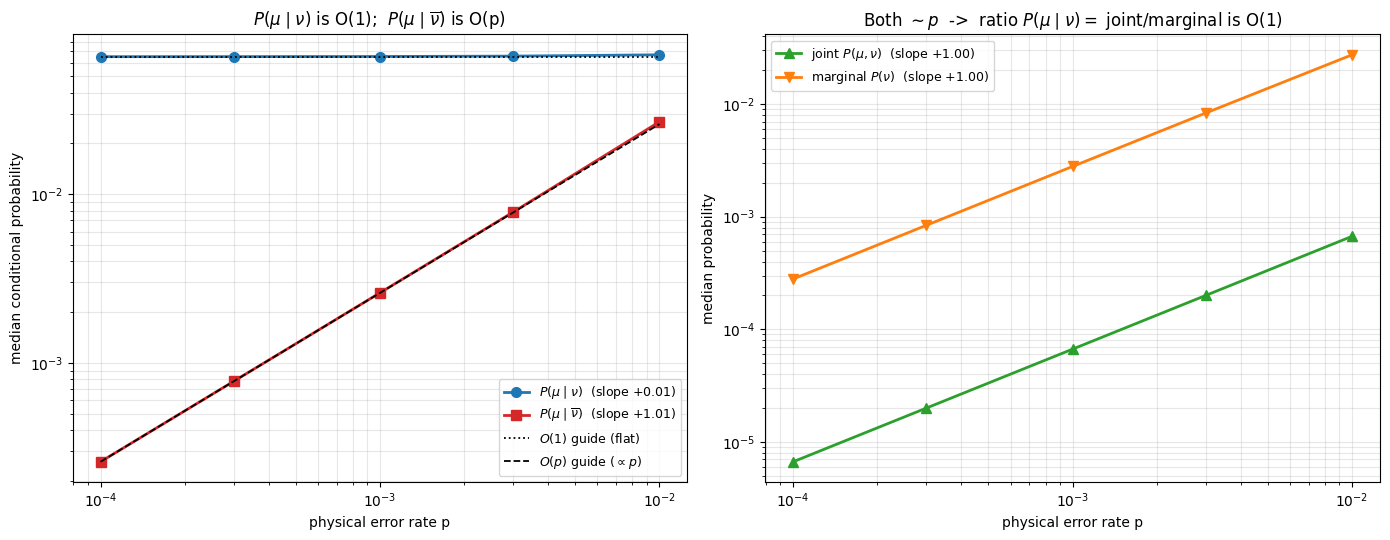

saved plots/conditional_scaling.png


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

# (1) the conditional vs p: O(1) vs O(p)
ax[0].loglog(P_GRID, med["cond"], "o-", color="#1f77b4", ms=7, lw=2,
             label=f"$P(\\mu\\mid\\nu)$  (slope {slope(med['cond']):+.2f})")
ax[0].loglog(P_GRID, med["neg"], "s-", color="#d62728", ms=7, lw=2,
             label=f"$P(\\mu\\mid\\overline{{\\nu}})$  (slope {slope(med['neg']):+.2f})")
ax[0].loglog(P_GRID, med["cond"][0] * np.ones_like(P_GRID), "k:", lw=1.3, label="$O(1)$ guide (flat)")
ax[0].loglog(P_GRID, med["neg"][0] * (P_GRID / P_GRID[0]), "k--", lw=1.3, label="$O(p)$ guide ($\\propto p$)")
ax[0].set_xlabel("physical error rate p"); ax[0].set_ylabel("median conditional probability")
ax[0].set_title(r"$P(\mu\mid\nu)$ is O(1);  $P(\mu\mid\overline{\nu})$ is O(p)")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3, which="both")

# (2) why: joint and marginal are BOTH O(p), so the ratio is O(1)
ax[1].loglog(P_GRID, med["joint"], "^-", color="#2ca02c", ms=7, lw=2,
             label=f"joint $P(\\mu,\\nu)$  (slope {slope(med['joint']):+.2f})")
ax[1].loglog(P_GRID, med["marg"], "v-", color="#ff7f0e", ms=7, lw=2,
             label=f"marginal $P(\\nu)$  (slope {slope(med['marg']):+.2f})")
ax[1].set_xlabel("physical error rate p"); ax[1].set_ylabel("median probability")
ax[1].set_title(r"Both $\sim p$  ->  ratio $P(\mu\mid\nu)=$ joint/marginal is O(1)")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "conditional_scaling.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/conditional_scaling.png")

## Conclusion

- **$P(e_\mu\mid e_\nu)$ is $O(1)$** — log-log slope $\approx 0$; it barely moves from ~0.065 across two
  decades of $p$ (the tiny upward drift toward high $p$ is the $O(p)$ coincidence correction). It does
  **not** vanish as $p\to0$.
- **$P(e_\mu\mid\lnot e_\nu)$ is $O(p)$** — slope $\approx 1$; it scales linearly and vanishes as $p\to0$.
- **Why:** both the joint $P(e_\mu,e_\nu)$ and the marginal $P(e_\nu)$ are $O(p)$ (a single shared fault
  sets each at leading order), so their ratio is $p$-independent.
- **Consequence:** the two hypotheses about $\mu$ diverge by a factor $\sim 1/p$ at low $p$
  ($P(\mu\mid\nu)=O(1)$ vs $P(\mu\mid\lnot\nu)=O(p)$). That large contrast is exactly the low-$p$
  "lever arm" $D=P(\mu\mid\nu)-P(\mu\mid\lnot\nu)=O(1)$ that makes the correlated reweight (and the Pearl
  $\alpha$ that damps it) matter most deep sub-threshold.